In [1]:
%load_ext autoreload
%autoreload 2
%cd ../../..
from rich import print



/Volumes/CrucialX/project-equinox


In [2]:
case_dir = "data/cases/LGAV_LFPG/"
batch_sgd_results_dir_path = f"{case_dir}batch_sgd_results/"

In [3]:
# Look for the latest checkpoint in the `batch_sgd_results_dir_path`
import re
from pathlib import Path

def get_latest_checkpoint(results_dir_path):
    directory = Path(results_dir_path)
    
    # Pattern to match 'checkpoint_iter_X.pt' and capture X
    pattern = re.compile(r"checkpoint_iter_(\d+)\.pt")
    
    checkpoints = []
    
    # Iterate through files in the directory
    for file in directory.glob("checkpoint_iter_*.pt"):
        match = pattern.search(file.name)
        if match:
            iteration = int(match.group(1))
            checkpoints.append((iteration, file.name))
            
    if not checkpoints:
        return None
    
    # Sort by the iteration number (the first element of the tuple) and get the last one
    latest_checkpoint = max(checkpoints, key=lambda x: x[0])
    
    return latest_checkpoint[1]


latest_checkpoint_filename = batch_sgd_results_dir_path + get_latest_checkpoint(batch_sgd_results_dir_path)
print(f"Latest checkpoint: {latest_checkpoint_filename}")

Latest checkpoint: data/cases/LGAV_LFPG/batch_sgd_results/checkpoint_iter_200.pt

In [4]:
from equinox.posttrain import load_cost_model_parameters
from rich.console import Console
from rich.table import Table

def print_params_table(params_dict):
    console = Console()
    
    # Initialize the table
    table = Table(title="Common Parameters", show_header=True, header_style="bold magenta")
    
    table.add_column("Parameter", style="dim", width=12)
    table.add_column("Value", justify="right")

    # Add rows, formatting floats to 6 decimal places for clarity
    for key, value in params_dict.items():
        table.add_row(key, f"{value:.6f}")

    console.print(table)

params = load_cost_model_parameters(latest_checkpoint_filename)
print("[bold red]Parameters retrieved from learned cost model[/bold red]")
print_params_table(params["common"])
print(params["preference_matrix"].shape)  # (num_nodes, num_nodes)

Parameters retrieved from learned cost model

     Common Parameters      
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Parameter    ┃     Value ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ bias         │  0.103047 │
│ ac_dist      │ -0.001956 │
│ time         │  0.046710 │
└──────────────┴───────────┘

torch.Size([600, 600])

Loading route graph from /Volumes/CrucialX/project-equinox/data/cases/LGAV_LFPG/graphs/routes.gml

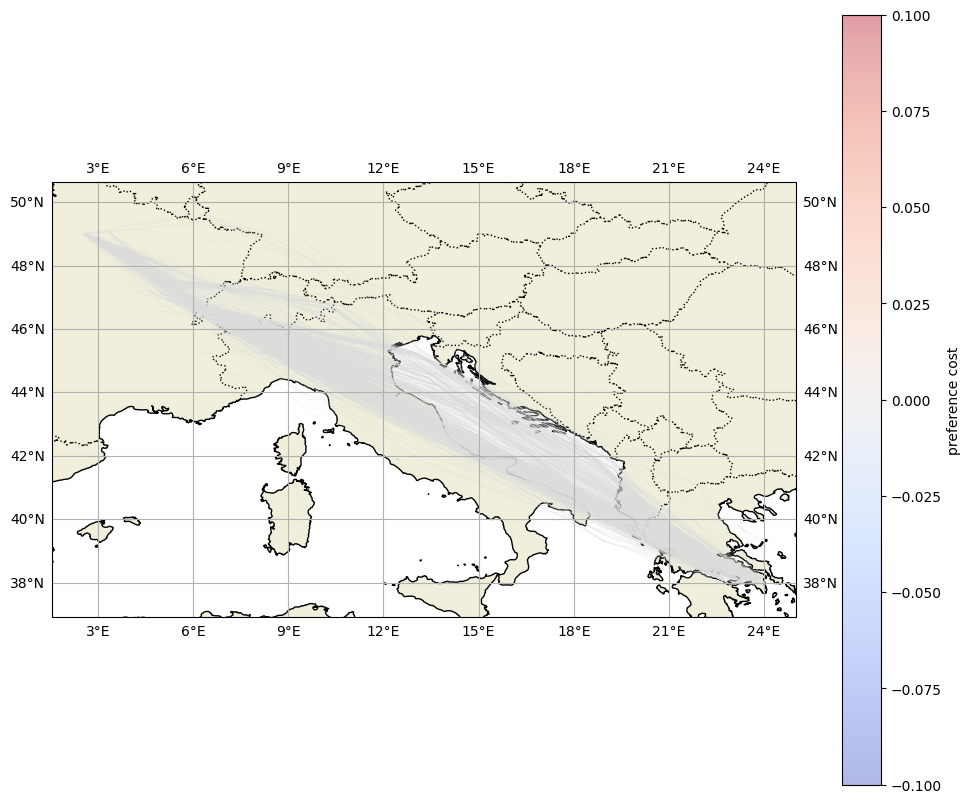

<GeoAxes: >

In [5]:
from equinox.posttrain import load_checkpoint_edge_preferences, plot_edge_preferences_cartopy

from pathlib import Path

def get_gml_path(batch_sgd_results_dir_path: str) -> str:
    """
    Recursively searches for a .gml file in the specified directory.
    Returns the absolute path to the .gml file.
    """
    directory = Path(batch_sgd_results_dir_path)
    
    # rglob("*.gml") searches recursively for all files ending in .gml
    # We use next() to get the first result since only one is guaranteed.
    try:
        gml_file = next(directory.rglob("*.gml"))
        return str(gml_file.absolute())
    except StopIteration:
        raise FileNotFoundError(f"No .gml file found in {batch_sgd_results_dir_path}")

gml_path = get_gml_path(case_dir)
print(f'Loading route graph from {gml_path}')

payload = load_checkpoint_edge_preferences(latest_checkpoint_filename, gml_path)
plot_edge_preferences_cartopy(
    payload["graph"],
    edge_preferences=payload["edge_preferences"],
    cmap="coolwarm",
    linewidth=0.3,
    alpha=0.4,
    percentile=0.01,
    percentile_mode="contrast" # upper = more preferred, lower = less preferred, contrast = half lowest, half highest
)

# Route cost decomposition and inspection

In [9]:
from equinox.posttrain.cost_back_envelope import compute_route_cost_breakdown, breakdown_to_frame

result = compute_route_cost_breakdown(
    checkpoint_path=latest_checkpoint_filename,
    case_dir=case_dir,
    flight_id="4690E2AEE4CA",
)

df = breakdown_to_frame(result["breakdown"])
print(result["totals"])
print(df.head())


All components initialized successfully:
  - Graph loaded with 600 nodes
  - Origin: LGAV (idx: 387)
  - Goal: LFPG (idx: 250)
  - Device: cpu
  - Distance matrix shape: (600, 600)
  - Charges matrix shape: (600, 600)


{
    'cost_bias': 0.618281677365303,
    'cost_ac_dist': -1.4090630401865487,
    'cost_time': 7.477065850532163,
    'cost_preference': 0.0,
    'cost_common': 6.686284487710918,
    'cost_total': 6.686284487710918
}

u_node    v_node  u_idx  v_idx    distance  airspace_charge  \
0      LGAV      LGKN    387    111   12.129164        25.460000   
1      LGKN     DIMIS    111    542  194.807591        25.483119   
2     DIMIS  NAKIT_39    542     13  442.938700        41.791970   
3  NAKIT_39     SIROD     13    191  317.660199       102.380900   
4     SIROD       CLM    191     92  175.664908        80.078738   

   tailwind_kts  feature_bias  feature_ac_dist  feature_time  weight_bias  \
0      2.343765           1.0         3.088085      1.608842     0.103047   
1      0.000000           1.0        49.643050     25.974345     0.103047   
2    -19.270811           1.0       185.112808     61.700769     0.103047   
3     -4.982763           1.0       325.223371     42.828930     0.103047   
4    -30.989161           1.0       140.670241     25.154229     0.103047   

   weight_ac_dist  weight_time  cost_bias  cost_ac_dist  cost_time  \
0       -0.001956      0.04671   0.103047     -0.006040   0.075149   
1       -0.001956      0.04671   0.103047     -0.097091   1.213265   
2       -0.001956      0.04671   0.103047     -0.362039   2.882051   
3       -0.001956      0.04671   0.103047     -0.636064   2.000545   
4       -0.001956      0.04671   0.103047     -0.275120   1.174957   

   cost_preference  cost_common  cost_total  
0              0.0     0.172157    0.172157  
1              0.0     1.219221    1.219221  
2              0.0     2.623058    2.623058  
3              0.0     1.467527    1.467527  
4              0.0     1.002885    1.002885